<a href="https://colab.research.google.com/github/Hiruni-Pavithrani-Gunasekara/EN3150_Assignment03_Systronix/blob/main/Systronix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Simple Convolutional Neural Network to Perform Classification.**
EN3150 Assignment 03

Team Systronix - UCI RealWaste dataset

### Dataset Setup & Extraction
Automatically downloads the `realwaste.zip` file from GitHub Releases and extracts it into the local Colab workspace.

In [ ]:
import os
import zipfile

dataset_url = "https://github.com/Hiruni-Pavithrani-Gunasekara/EN3150_Assignment03_Systronix/releases/download/v1.0.0/realwaste.zip"
zip_path = "/content/realwaste.zip"

if not os.path.exists(zip_path):
    print("Downloading dataset from GitHub Release...")
    !wget -O {zip_path} "{dataset_url}"

print("Extracting dataset...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/')

print("Dataset ready!")

--2026-09-24 16:02:24--  https://github.com/Hiruni-Pavithrani-Gunasekara/EN3150_Assignment03_Systronix/releases/download/v1.0.0/realwaste.zip
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/1346976624/2b8429de-6dc2-47b3-84bf-00dd1ef9ad53?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-09-24T16%3A36%3A20Z&rscd=attachment%3B+filename%3Drealwaste.zip&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-09-24T15%3A35%3A52Z&ske=2026-09-24T16%3A36%3A20Z&sks=b&skv=2018-11-09&sig=VivyUXlE0GOVbpWtt9Te32k6411wnT1%2BPP6Vrpk0PyQ%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc5MDI2OTM0NSwibmJmIjoxNzkwMjY1NzQ1LCJwYXRo

# 1) Resource-Constrained CNN for Edge Image Classification


## **1. Data Preparation**

In [ ]:
import os
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# 1. Image Transformations
transform = transforms.Compose([
    transforms.Resize((64, 64)), # Downscale to 64x64
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Load Dataset
data_dir = "/content/realwaste-main/RealWaste"
full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)

# 3. Calculate Splits (70% Train, 15% Val, 15% Test)
total_count = len(full_dataset)
train_count = int(0.70 * total_count)
val_count = int(0.15 * total_count)
test_count = total_count - train_count - val_count

generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_count, val_count, test_count], generator=generator
)

# 4. DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

num_classes = len(full_dataset.classes)

print("No of Classes:", num_classes)
print("Classes:", full_dataset.classes)
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))
print(f"Ratios: {round(len(train_dataset)/total_count * 100)}% / "f"{round(len(val_dataset)/total_count * 100)}% / {round(len(test_dataset)/total_count * 100)}%")

No of Classes: 9
Classes: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']
Train: 3326
Validation: 712
Test: 714
Ratios: 70% / 15% / 15%


## **2. Custom Arcitecture Design**

### Design of Model A - Standard CNN

 This model uses standard 2D convolutional layers and max-pooling layers for feature extraction, followed by fully connected layers for image classification.

In [ ]:
# Define Model A: Standard CNN

class ModelA(nn.Module):
    def __init__(self, num_classes=9):
        super(ModelA, self).__init__()

        # Feature Extractor: Interleaved Conv2d and MaxPooling2d
        self.features = nn.Sequential(
            # Conv Block 1
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # Output: 32 x 32 x 32

            # Conv Block 2
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # Output: 64 x 16 x 16

            # Conv Block 3
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)   # Output: 128 x 8 x 8
        )

        # Classifier: Fully Connected Layers
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Instantiate Model A
model_a = ModelA(num_classes=num_classes)

# Count and display trainable parameters
total_params_a = sum(p.numel() for p in model_a.parameters() if p.requires_grad)
print(model_a)
print(f"\nTotal Trainable Parameters in Model A: {total_params_a:,}")

ModelA(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=9, bias=True)
  )
)

Total Trainable Parameters in Model A: 618,185


### Design of Model B - (Lightweight CNN)

This model replaces standard convolutions with depthwise separable convolutions to reduce the number of parameters and computational cost

In [ ]:
# Custom Depthwise Separable Convolution Block
class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, padding=1):
        super(DepthwiseSeparableConv, self).__init__()
        # 1. Depthwise Conv (groups = in_channels)
        self.depthwise = nn.Conv2d(
            in_channels, in_channels, kernel_size=kernel_size,
            padding=padding, groups=in_channels, bias=False
        )
        # 2. Pointwise Conv (1x1 conv)
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=True)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        x = self.relu(x)
        return x

# Model B: Lightweight CNN (<100k parameters)
class ModelB(nn.Module):
    def __init__(self, num_classes=9):
        super(ModelB, self).__init__()

        self.features = nn.Sequential(
            # Block 1: 3 -> 32 channels
            DepthwiseSeparableConv(3, 32),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 32 x 32 x 32

            # Block 2: 32 -> 64 channels
            DepthwiseSeparableConv(32, 64),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 64 x 16 x 16

            # Block 3: 64 -> 128 channels
            DepthwiseSeparableConv(64, 128),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 128 x 8 x 8

            # Block 4: 128 -> 128 channels
            DepthwiseSeparableConv(128, 128),
            nn.MaxPool2d(kernel_size=2, stride=2)   # 128 x 4 x 4
        )

        # Global Average Pooling reduces (128, 4, 4) -> (128, 1, 1)
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.global_pool(x)
        x = self.classifier(x)
        return x

# Instantiate Model B
model_b = ModelB(num_classes=num_classes)

# Count and display trainable parameters
total_params_b = sum(p.numel() for p in model_b.parameters() if p.requires_grad)
print(model_b)
print(f"\nTotal Trainable Parameters in Model B: {total_params_b:,}")

ModelB(
  (features): Sequential(
    (0): DepthwiseSeparableConv(
      (depthwise): Conv2d(3, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=3, bias=False)
      (pointwise): Conv2d(3, 32, kernel_size=(1, 1), stride=(1, 1))
      (relu): ReLU()
    )
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): DepthwiseSeparableConv(
      (depthwise): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
      (pointwise): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1))
      (relu): ReLU()
    )
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): DepthwiseSeparableConv(
      (depthwise): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64, bias=False)
      (pointwise): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1))
      (relu): ReLU()
    )
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6

## **3. Optimizer Selection and Testing**
For this assignment, **Adam** is chosen as the selected optimizer with a learning rate of 0.001.

Standard SGD with a learning rate of 0.01
SGD with Momentum with a learning rate of 0.01 and momentum of 0.9
were also tested for the models as well.


MODEL B - ADAM
Epoch [1/15] | Train Loss: 2.1590 | Train Acc: 17.89% | Val Loss: 2.1096 | Val Acc: 22.47%
Epoch [2/15] | Train Loss: 2.0588 | Train Acc: 23.60% | Val Loss: 1.9384 | Val Acc: 32.02%
Epoch [3/15] | Train Loss: 1.9227 | Train Acc: 30.91% | Val Loss: 1.8617 | Val Acc: 33.99%
Epoch [4/15] | Train Loss: 1.8325 | Train Acc: 33.82% | Val Loss: 1.7939 | Val Acc: 36.24%
Epoch [5/15] | Train Loss: 1.7478 | Train Acc: 36.41% | Val Loss: 1.7170 | Val Acc: 38.62%
Epoch [6/15] | Train Loss: 1.6712 | Train Acc: 38.94% | Val Loss: 1.6272 | Val Acc: 41.15%
Epoch [7/15] | Train Loss: 1.5857 | Train Acc: 43.02% | Val Loss: 1.6497 | Val Acc: 40.73%
Epoch [8/15] | Train Loss: 1.5186 | Train Acc: 47.02% | Val Loss: 1.4848 | Val Acc: 45.37%
Epoch [9/15] | Train Loss: 1.4357 | Train Acc: 49.67% | Val Loss: 1.4459 | Val Acc: 49.72%
Epoch [10/15] | Train Loss: 1.3716 | Train Acc: 51.86% | Val Loss: 1.3682 | Val Acc: 49.58%
Epoch [11/15] | Train Loss: 1.3505 | Train Acc: 53.22% | Val Loss: 1.3944

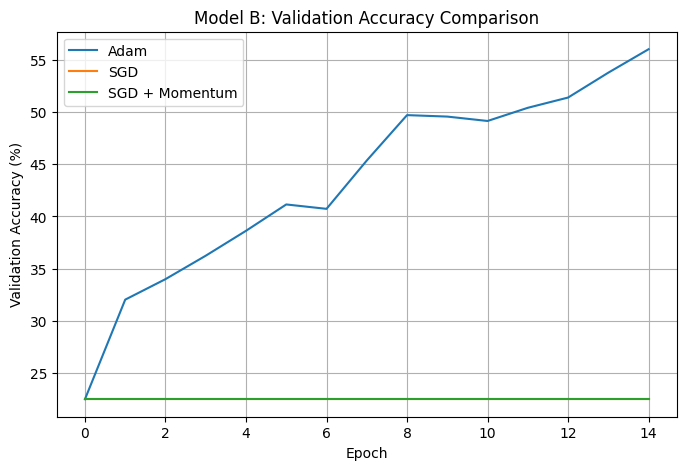

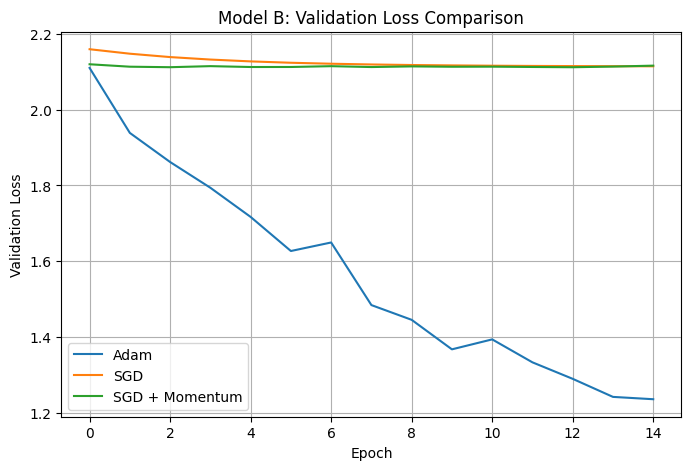

In [ ]:
# ============================================================
# PART 3B: OPTIMIZER COMPARISON FOR MODEL B
# ============================================================

# Loss function for multi-class classification
criterion = nn.CrossEntropyLoss()

# Number of training epochs
epochs = 15


# ------------------------------------------------------------
# Function to train Model B
# ------------------------------------------------------------
def train_model_b(model, optimizer, epochs):

    # Store results for each epoch
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    # Move model to CPU or GPU
    model = model.to(device)

    for epoch in range(epochs):

        # ==========================
        # Training phase
        # ==========================
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:

            # Move data to selected device
            images = images.to(device)
            labels = labels.to(device)

            # Clear previous gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)

            # Calculate loss
            loss = criterion(outputs, labels)

            # Backpropagation
            loss.backward()

            # Update model parameters
            optimizer.step()

            # Accumulate loss
            running_loss += loss.item() * images.size(0)

            # Calculate training accuracy
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_accuracy = 100 * correct / total


        # ==========================
        # Validation phase
        # ==========================
        model.eval()

        running_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                # Forward pass
                outputs = model(images)

                # Validation loss
                loss = criterion(outputs, labels)

                running_loss += loss.item() * images.size(0)

                # Calculate validation accuracy
                _, predicted = torch.max(outputs, 1)

                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        epoch_val_loss = running_loss / len(val_loader.dataset)
        epoch_val_accuracy = 100 * correct / total


        # Store results
        train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)

        train_accuracies.append(epoch_train_accuracy)
        val_accuracies.append(epoch_val_accuracy)


        # Display results
        print(
            f"Epoch [{epoch + 1}/{epochs}] | "
            f"Train Loss: {epoch_train_loss:.4f} | "
            f"Train Acc: {epoch_train_accuracy:.2f}% | "
            f"Val Loss: {epoch_val_loss:.4f} | "
            f"Val Acc: {epoch_val_accuracy:.2f}%"
        )

    return {
        "train_loss": train_losses,
        "val_loss": val_losses,
        "train_accuracy": train_accuracies,
        "val_accuracy": val_accuracies
    }


# ------------------------------------------------------------
# Function to evaluate Model B on the test set
# ------------------------------------------------------------
def test_model_b(model):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_accuracy = 100 * correct / total

    return test_accuracy


# ============================================================
# 1. MODEL B + ADAM
# ============================================================

print("\n" + "=" * 60)
print("MODEL B - ADAM")
print("=" * 60)

# Create a fresh Model B
model_b_adam = ModelB(num_classes=num_classes)

# Adam optimizer
optimizer_b_adam = optim.Adam(
    model_b_adam.parameters(),
    lr=0.001
)

# Train Model B
history_b_adam = train_model_b(
    model_b_adam,
    optimizer_b_adam,
    epochs
)

# Test Model B
test_acc_b_adam = test_model_b(model_b_adam)

print(f"\nModel B + Adam Test Accuracy: {test_acc_b_adam:.2f}%")


# ============================================================
# 2. MODEL B + STANDARD SGD
# ============================================================

print("\n" + "=" * 60)
print("MODEL B - STANDARD SGD")
print("=" * 60)

# Create a fresh Model B
model_b_sgd = ModelB(num_classes=num_classes)

# Standard SGD optimizer
optimizer_b_sgd = optim.SGD(
    model_b_sgd.parameters(),
    lr=0.01
)

# Train Model B
history_b_sgd = train_model_b(
    model_b_sgd,
    optimizer_b_sgd,
    epochs
)

# Test Model B
test_acc_b_sgd = test_model_b(model_b_sgd)

print(f"\nModel B + SGD Test Accuracy: {test_acc_b_sgd:.2f}%")


# ============================================================
# 3. MODEL B + SGD WITH MOMENTUM
# ============================================================

print("\n" + "=" * 60)
print("MODEL B - SGD WITH MOMENTUM")
print("=" * 60)

# Create a fresh Model B
model_b_momentum = ModelB(num_classes=num_classes)

# SGD with Momentum
optimizer_b_momentum = optim.SGD(
    model_b_momentum.parameters(),
    lr=0.01,
    momentum=0.9
)

# Train Model B
history_b_momentum = train_model_b(
    model_b_momentum,
    optimizer_b_momentum,
    epochs
)

# Test Model B
test_acc_b_momentum = test_model_b(model_b_momentum)

print(f"\nModel B + SGD Momentum Test Accuracy: {test_acc_b_momentum:.2f}%")


# ============================================================
# FINAL TEST ACCURACY COMPARISON FOR MODEL B
# ============================================================

print("\n" + "=" * 60)
print("MODEL B - FINAL TEST ACCURACY COMPARISON")
print("=" * 60)

print(f"Adam             : {test_acc_b_adam:.2f}%")
print(f"Standard SGD     : {test_acc_b_sgd:.2f}%")
print(f"SGD + Momentum   : {test_acc_b_momentum:.2f}%")


# ============================================================
# PLOT 1: VALIDATION ACCURACY
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history_b_adam["val_accuracy"],
    label="Adam"
)

plt.plot(
    history_b_sgd["val_accuracy"],
    label="SGD"
)

plt.plot(
    history_b_momentum["val_accuracy"],
    label="SGD + Momentum"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Model B: Validation Accuracy Comparison")
plt.legend()
plt.grid(True)
plt.show()


# ============================================================
# PLOT 2: VALIDATION LOSS
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history_b_adam["val_loss"],
    label="Adam"
)

plt.plot(
    history_b_sgd["val_loss"],
    label="SGD"
)

plt.plot(
    history_b_momentum["val_loss"],
    label="SGD + Momentum"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Model B: Validation Loss Comparison")
plt.legend()
plt.grid(True)
plt.show()

### Optimizer comparison for model A


MODEL A - ADAM
Epoch [1/15] | Train Loss: 1.7836 | Train Acc: 36.20% | Val Loss: 1.4105 | Val Acc: 49.16%
Epoch [2/15] | Train Loss: 1.3508 | Train Acc: 51.20% | Val Loss: 1.2513 | Val Acc: 52.95%
Epoch [3/15] | Train Loss: 1.1043 | Train Acc: 60.40% | Val Loss: 1.1926 | Val Acc: 54.63%
Epoch [4/15] | Train Loss: 0.9447 | Train Acc: 66.69% | Val Loss: 1.0150 | Val Acc: 62.08%
Epoch [5/15] | Train Loss: 0.8163 | Train Acc: 70.90% | Val Loss: 1.1377 | Val Acc: 59.83%
Epoch [6/15] | Train Loss: 0.6883 | Train Acc: 75.29% | Val Loss: 1.0470 | Val Acc: 62.36%
Epoch [7/15] | Train Loss: 0.5797 | Train Acc: 79.80% | Val Loss: 1.0787 | Val Acc: 64.04%
Epoch [8/15] | Train Loss: 0.4923 | Train Acc: 82.35% | Val Loss: 0.9897 | Val Acc: 67.98%
Epoch [9/15] | Train Loss: 0.3575 | Train Acc: 88.09% | Val Loss: 1.1054 | Val Acc: 67.70%
Epoch [10/15] | Train Loss: 0.2748 | Train Acc: 90.83% | Val Loss: 1.0087 | Val Acc: 70.65%
Epoch [11/15] | Train Loss: 0.2121 | Train Acc: 92.99% | Val Loss: 1.3286

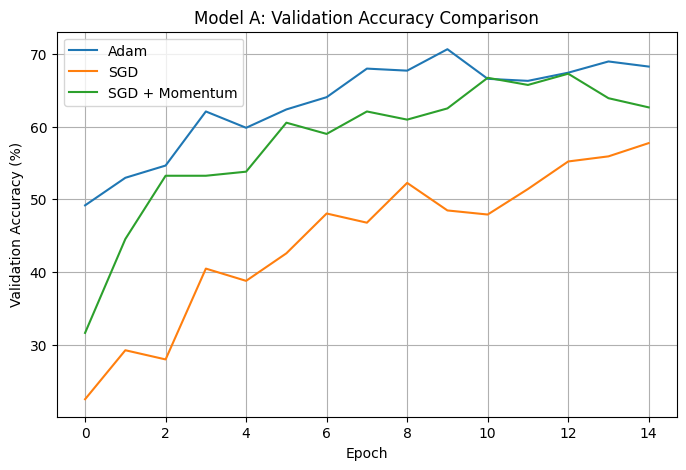

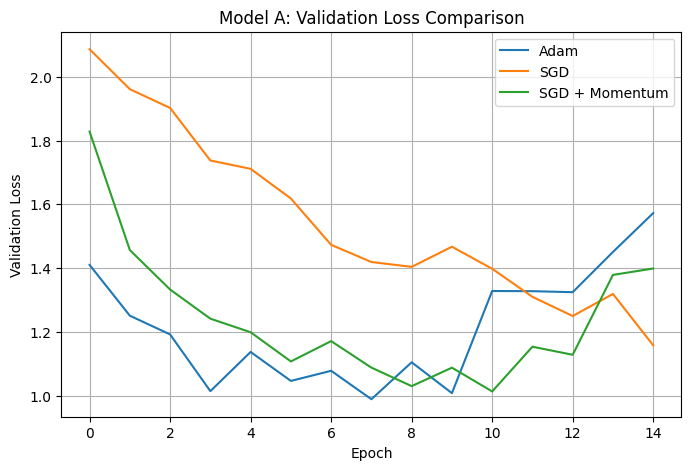

In [ ]:
# ============================================================
# PART 3A: OPTIMIZER COMPARISON FOR MODEL A
# ============================================================

import torch.optim as optim
import matplotlib.pyplot as plt

# Loss function for multi-class classification
criterion = nn.CrossEntropyLoss()

# Number of training epochs
epochs = 15


# ------------------------------------------------------------
# Function to train Model A
# ------------------------------------------------------------
def train_model_a(model, optimizer, epochs):

    # Store results for each epoch
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    # Move model to CPU or GPU
    model = model.to(device)

    for epoch in range(epochs):

        # ==========================
        # Training phase
        # ==========================
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:

            # Move data to selected device
            images = images.to(device)
            labels = labels.to(device)

            # Clear previous gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)

            # Calculate loss
            loss = criterion(outputs, labels)

            # Backpropagation
            loss.backward()

            # Update model parameters
            optimizer.step()

            # Accumulate loss
            running_loss += loss.item() * images.size(0)

            # Calculate training accuracy
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_accuracy = 100 * correct / total


        # ==========================
        # Validation phase
        # ==========================
        model.eval()

        running_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                # Forward pass
                outputs = model(images)

                # Validation loss
                loss = criterion(outputs, labels)

                running_loss += loss.item() * images.size(0)

                # Validation accuracy
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        epoch_val_loss = running_loss / len(val_loader.dataset)
        epoch_val_accuracy = 100 * correct / total


        # Store results
        train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)

        train_accuracies.append(epoch_train_accuracy)
        val_accuracies.append(epoch_val_accuracy)


        # Display results
        print(
            f"Epoch [{epoch + 1}/{epochs}] | "
            f"Train Loss: {epoch_train_loss:.4f} | "
            f"Train Acc: {epoch_train_accuracy:.2f}% | "
            f"Val Loss: {epoch_val_loss:.4f} | "
            f"Val Acc: {epoch_val_accuracy:.2f}%"
        )

    return {
        "train_loss": train_losses,
        "val_loss": val_losses,
        "train_accuracy": train_accuracies,
        "val_accuracy": val_accuracies
    }


# ------------------------------------------------------------
# Function to evaluate Model A on the test set
# ------------------------------------------------------------
def test_model_a(model):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_accuracy = 100 * correct / total

    return test_accuracy


# ============================================================
# 1. MODEL A + ADAM
# ============================================================

print("\n" + "=" * 60)
print("MODEL A - ADAM")
print("=" * 60)

# Create a fresh Model A
model_a_adam = ModelA(num_classes=num_classes)

# Adam optimizer
optimizer_a_adam = optim.Adam(
    model_a_adam.parameters(),
    lr=0.001
)

# Train Model A
history_a_adam = train_model_a(
    model_a_adam,
    optimizer_a_adam,
    epochs
)

# Test Model A
test_acc_a_adam = test_model_a(model_a_adam)

print(f"\nModel A + Adam Test Accuracy: {test_acc_a_adam:.2f}%")


# ============================================================
# 2. MODEL A + STANDARD SGD
# ============================================================

print("\n" + "=" * 60)
print("MODEL A - STANDARD SGD")
print("=" * 60)

# Create a fresh Model A
model_a_sgd = ModelA(num_classes=num_classes)

# Standard SGD optimizer
optimizer_a_sgd = optim.SGD(
    model_a_sgd.parameters(),
    lr=0.01
)

# Train Model A
history_a_sgd = train_model_a(
    model_a_sgd,
    optimizer_a_sgd,
    epochs
)

# Test Model A
test_acc_a_sgd = test_model_a(model_a_sgd)

print(f"\nModel A + SGD Test Accuracy: {test_acc_a_sgd:.2f}%")


# ============================================================
# 3. MODEL A + SGD WITH MOMENTUM
# ============================================================

print("\n" + "=" * 60)
print("MODEL A - SGD WITH MOMENTUM")
print("=" * 60)

# Create a fresh Model A
model_a_momentum = ModelA(num_classes=num_classes)

# SGD with Momentum
optimizer_a_momentum = optim.SGD(
    model_a_momentum.parameters(),
    lr=0.01,
    momentum=0.9
)

# Train Model A
history_a_momentum = train_model_a(
    model_a_momentum,
    optimizer_a_momentum,
    epochs
)

# Test Model A
test_acc_a_momentum = test_model_a(model_a_momentum)

print(f"\nModel A + SGD Momentum Test Accuracy: {test_acc_a_momentum:.2f}%")


# ============================================================
# FINAL TEST ACCURACY COMPARISON FOR MODEL A
# ============================================================

print("\n" + "=" * 60)
print("MODEL A - FINAL TEST ACCURACY COMPARISON")
print("=" * 60)

print(f"Adam             : {test_acc_a_adam:.2f}%")
print(f"Standard SGD     : {test_acc_a_sgd:.2f}%")
print(f"SGD + Momentum   : {test_acc_a_momentum:.2f}%")


# ============================================================
# PLOT 1: VALIDATION ACCURACY
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history_a_adam["val_accuracy"],
    label="Adam"
)

plt.plot(
    history_a_sgd["val_accuracy"],
    label="SGD"
)

plt.plot(
    history_a_momentum["val_accuracy"],
    label="SGD + Momentum"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Model A: Validation Accuracy Comparison")
plt.legend()
plt.grid(True)
plt.show()


# ============================================================
# PLOT 2: VALIDATION LOSS
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history_a_adam["val_loss"],
    label="Adam"
)

plt.plot(
    history_a_sgd["val_loss"],
    label="SGD"
)

plt.plot(
    history_a_momentum["val_loss"],
    label="SGD + Momentum"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Model A: Validation Loss Comparison")
plt.legend()
plt.grid(True)
plt.show()

### Optimizer comparison for model B


MODEL B - ADAM
Epoch [1/15] | Train Loss: 2.1590 | Train Acc: 17.89% | Val Loss: 2.1096 | Val Acc: 22.47%
Epoch [2/15] | Train Loss: 2.0588 | Train Acc: 23.60% | Val Loss: 1.9384 | Val Acc: 32.02%
Epoch [3/15] | Train Loss: 1.9227 | Train Acc: 30.91% | Val Loss: 1.8617 | Val Acc: 33.99%
Epoch [4/15] | Train Loss: 1.8325 | Train Acc: 33.82% | Val Loss: 1.7939 | Val Acc: 36.24%
Epoch [5/15] | Train Loss: 1.7478 | Train Acc: 36.41% | Val Loss: 1.7170 | Val Acc: 38.62%
Epoch [6/15] | Train Loss: 1.6712 | Train Acc: 38.94% | Val Loss: 1.6272 | Val Acc: 41.15%
Epoch [7/15] | Train Loss: 1.5857 | Train Acc: 43.02% | Val Loss: 1.6497 | Val Acc: 40.73%
Epoch [8/15] | Train Loss: 1.5186 | Train Acc: 47.02% | Val Loss: 1.4848 | Val Acc: 45.37%
Epoch [9/15] | Train Loss: 1.4357 | Train Acc: 49.67% | Val Loss: 1.4459 | Val Acc: 49.72%
Epoch [10/15] | Train Loss: 1.3716 | Train Acc: 51.86% | Val Loss: 1.3682 | Val Acc: 49.58%
Epoch [11/15] | Train Loss: 1.3505 | Train Acc: 53.22% | Val Loss: 1.3944

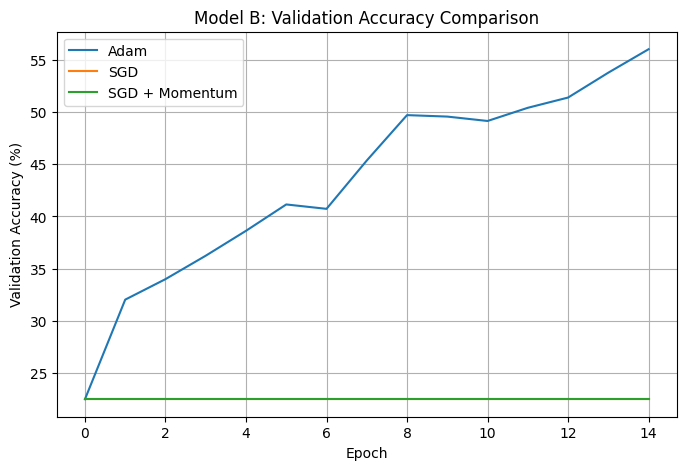

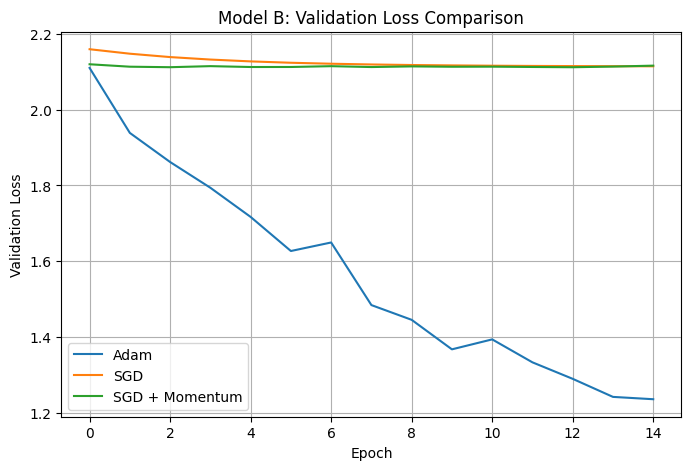

In [ ]:
# ============================================================
# PART 3B: OPTIMIZER COMPARISON FOR MODEL B
# ============================================================

# Loss function for multi-class classification
criterion = nn.CrossEntropyLoss()

# Number of training epochs
epochs = 15


# ------------------------------------------------------------
# Function to train Model B
# ------------------------------------------------------------
def train_model_b(model, optimizer, epochs):

    # Store results for each epoch
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    # Move model to CPU or GPU
    model = model.to(device)

    for epoch in range(epochs):

        # ==========================
        # Training phase
        # ==========================
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:

            # Move data to selected device
            images = images.to(device)
            labels = labels.to(device)

            # Clear previous gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)

            # Calculate loss
            loss = criterion(outputs, labels)

            # Backpropagation
            loss.backward()

            # Update model parameters
            optimizer.step()

            # Accumulate loss
            running_loss += loss.item() * images.size(0)

            # Calculate training accuracy
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_accuracy = 100 * correct / total


        # ==========================
        # Validation phase
        # ==========================
        model.eval()

        running_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                # Forward pass
                outputs = model(images)

                # Validation loss
                loss = criterion(outputs, labels)

                running_loss += loss.item() * images.size(0)

                # Calculate validation accuracy
                _, predicted = torch.max(outputs, 1)

                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        epoch_val_loss = running_loss / len(val_loader.dataset)
        epoch_val_accuracy = 100 * correct / total


        # Store results
        train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)

        train_accuracies.append(epoch_train_accuracy)
        val_accuracies.append(epoch_val_accuracy)


        # Display results
        print(
            f"Epoch [{epoch + 1}/{epochs}] | "
            f"Train Loss: {epoch_train_loss:.4f} | "
            f"Train Acc: {epoch_train_accuracy:.2f}% | "
            f"Val Loss: {epoch_val_loss:.4f} | "
            f"Val Acc: {epoch_val_accuracy:.2f}%"
        )

    return {
        "train_loss": train_losses,
        "val_loss": val_losses,
        "train_accuracy": train_accuracies,
        "val_accuracy": val_accuracies
    }


# ------------------------------------------------------------
# Function to evaluate Model B on the test set
# ------------------------------------------------------------
def test_model_b(model):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_accuracy = 100 * correct / total

    return test_accuracy


# ============================================================
# 1. MODEL B + ADAM
# ============================================================

print("\n" + "=" * 60)
print("MODEL B - ADAM")
print("=" * 60)

# Create a fresh Model B
model_b_adam = ModelB(num_classes=num_classes)

# Adam optimizer
optimizer_b_adam = optim.Adam(
    model_b_adam.parameters(),
    lr=0.001
)

# Train Model B
history_b_adam = train_model_b(
    model_b_adam,
    optimizer_b_adam,
    epochs
)

# Test Model B
test_acc_b_adam = test_model_b(model_b_adam)

print(f"\nModel B + Adam Test Accuracy: {test_acc_b_adam:.2f}%")


# ============================================================
# 2. MODEL B + STANDARD SGD
# ============================================================

print("\n" + "=" * 60)
print("MODEL B - STANDARD SGD")
print("=" * 60)

# Create a fresh Model B
model_b_sgd = ModelB(num_classes=num_classes)

# Standard SGD optimizer
optimizer_b_sgd = optim.SGD(
    model_b_sgd.parameters(),
    lr=0.01
)

# Train Model B
history_b_sgd = train_model_b(
    model_b_sgd,
    optimizer_b_sgd,
    epochs
)

# Test Model B
test_acc_b_sgd = test_model_b(model_b_sgd)

print(f"\nModel B + SGD Test Accuracy: {test_acc_b_sgd:.2f}%")


# ============================================================
# 3. MODEL B + SGD WITH MOMENTUM
# ============================================================

print("\n" + "=" * 60)
print("MODEL B - SGD WITH MOMENTUM")
print("=" * 60)

# Create a fresh Model B
model_b_momentum = ModelB(num_classes=num_classes)

# SGD with Momentum
optimizer_b_momentum = optim.SGD(
    model_b_momentum.parameters(),
    lr=0.01,
    momentum=0.9
)

# Train Model B
history_b_momentum = train_model_b(
    model_b_momentum,
    optimizer_b_momentum,
    epochs
)

# Test Model B
test_acc_b_momentum = test_model_b(model_b_momentum)

print(f"\nModel B + SGD Momentum Test Accuracy: {test_acc_b_momentum:.2f}%")


# ============================================================
# FINAL TEST ACCURACY COMPARISON FOR MODEL B
# ============================================================

print("\n" + "=" * 60)
print("MODEL B - FINAL TEST ACCURACY COMPARISON")
print("=" * 60)

print(f"Adam             : {test_acc_b_adam:.2f}%")
print(f"Standard SGD     : {test_acc_b_sgd:.2f}%")
print(f"SGD + Momentum   : {test_acc_b_momentum:.2f}%")


# ============================================================
# PLOT 1: VALIDATION ACCURACY
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history_b_adam["val_accuracy"],
    label="Adam"
)

plt.plot(
    history_b_sgd["val_accuracy"],
    label="SGD"
)

plt.plot(
    history_b_momentum["val_accuracy"],
    label="SGD + Momentum"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Model B: Validation Accuracy Comparison")
plt.legend()
plt.grid(True)
plt.show()


# ============================================================
# PLOT 2: VALIDATION LOSS
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history_b_adam["val_loss"],
    label="Adam"
)

plt.plot(
    history_b_sgd["val_loss"],
    label="SGD"
)

plt.plot(
    history_b_momentum["val_loss"],
    label="SGD + Momentum"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Model B: Validation Loss Comparison")
plt.legend()
plt.grid(True)
plt.show()

# 2) Compare with Lightweight State-of-the-Art Networks

## **5. SOTA Fine-Tuning & Evaluation**

In [ ]:
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

# Device Configuration (GPU if available, else CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(full_dataset.classes)

#Training Loop Function
def train_model(model, train_loader, val_loader, epochs=20, lr=1e-4):
    """
    Trains a CNN model and evaluates accuracy on the validation set after each epoch.
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        # --- Training Phase ---
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()           # Clear previous gradients
            outputs = model(images)          # Forward pass
            loss = criterion(outputs, labels) # Calculate Cross-Entropy Loss
            loss.backward()                 # Backward pass (Backpropagation)
            optimizer.step()                # Update model weights

            running_loss += loss.item() * images.size(0)

        # --- Validation Phase ---
        model.eval()
        correct, total = 0, 0
        with torch.no_grad(): # Disable gradient computation for validation efficiency
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, preds = torch.max(outputs, 1) # Extract index of highest logit
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        val_acc = correct / total
        print(f"Epoch {epoch+1:02d}/{epochs} - Train Loss: {epoch_loss:.4f} - Val Acc: {val_acc*100:.2f}%")

    return model

# Evaluation Loop Function
def evaluate_model(model, test_loader):
    """
    Evaluates the trained model on the unseen test dataset.
    Returns overall test accuracy along with predicted and ground-truth labels for confusion matrix generation.
    """
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            # Collect predictions for evaluation metrics
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = correct / total
    return acc, all_preds, all_labels


# --- 1. MobileNetV2 Architecture Setup ---
mobilenet = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
# Replace final Linear classification head (originally 1,000 classes for ImageNet) to match RealWaste class count
mobilenet.classifier[1] = nn.Linear(mobilenet.last_channel, num_classes)
mobilenet = mobilenet.to(device)

# --- 2. SqueezeNet 1.1 Architecture Setup ---
squeezenet = models.squeezenet1_1(weights=models.SqueezeNet1_1_Weights.IMAGENET1K_V1)
# SqueezeNet utilizes a 1x1 Conv2d layer as its classifier inside the Fire module pipeline
squeezenet.classifier[1] = nn.Conv2d(512, num_classes, kernel_size=1)
squeezenet.num_classes = num_classes
squeezenet = squeezenet.to(device)

print("Pre-trained MobileNetV2 and SqueezeNet 1.1 initialized successfully!")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 103MB/s] 


Downloading: "https://download.pytorch.org/models/squeezenet1_1-b8a52dc0.pth" to /root/.cache/torch/hub/checkpoints/squeezenet1_1-b8a52dc0.pth


100%|██████████| 4.73M/4.73M [00:00<00:00, 58.8MB/s]

Pre-trained MobileNetV2 and SqueezeNet 1.1 initialized successfully!


Training the models

In [ ]:
# Train & Evaluate MobileNetV2
print("=== Training MobileNetV2 ===")
mobilenet = train_model(mobilenet, train_loader, val_loader, epochs=20, lr=1e-4)
mb_acc, mb_preds, mb_labels = evaluate_model(mobilenet, test_loader)
print(f"\nMobileNetV2 Final Test Accuracy: {mb_acc * 100:.2f}%\n")

# Train & Evaluate SqueezeNet 1.1
print("=== Training SqueezeNet 1.1 ===")
squeezenet = train_model(squeezenet, train_loader, val_loader, epochs=20, lr=1e-4)
sq_acc, sq_preds, sq_labels = evaluate_model(squeezenet, test_loader)
print(f"\nSqueezeNet 1.1 Final Test Accuracy: {sq_acc * 100:.2f}%\n")

=== Training MobileNetV2 ===
Epoch 01/20 - Train Loss: 1.3493 - Val Acc: 71.49%
Epoch 02/20 - Train Loss: 0.6844 - Val Acc: 77.39%
Epoch 03/20 - Train Loss: 0.4318 - Val Acc: 79.49%
Epoch 04/20 - Train Loss: 0.2509 - Val Acc: 81.74%
Epoch 05/20 - Train Loss: 0.1939 - Val Acc: 82.44%
Epoch 06/20 - Train Loss: 0.1203 - Val Acc: 79.63%
Epoch 07/20 - Train Loss: 0.0832 - Val Acc: 82.30%
Epoch 08/20 - Train Loss: 0.0726 - Val Acc: 82.16%
Epoch 09/20 - Train Loss: 0.0635 - Val Acc: 82.44%
Epoch 10/20 - Train Loss: 0.0620 - Val Acc: 83.15%
Epoch 11/20 - Train Loss: 0.0609 - Val Acc: 82.87%
Epoch 12/20 - Train Loss: 0.0527 - Val Acc: 84.13%
Epoch 13/20 - Train Loss: 0.0483 - Val Acc: 82.58%
Epoch 14/20 - Train Loss: 0.0360 - Val Acc: 82.02%
Epoch 15/20 - Train Loss: 0.0291 - Val Acc: 82.87%
Epoch 16/20 - Train Loss: 0.0364 - Val Acc: 83.71%
Epoch 17/20 - Train Loss: 0.0257 - Val Acc: 82.44%
Epoch 18/20 - Train Loss: 0.0318 - Val Acc: 82.72%
Epoch 19/20 - Train Loss: 0.0463 - Val Acc: 83.85%
Ep

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(labels, preds, class_names, title="Confusion Matrix"):
    cm = confusion_matrix(labels, preds)

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.figure.colorbar(im, ax=ax)

    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels=class_names,
           yticklabels=class_names,
           ylabel='True label',
           xlabel='Predicted label',
           title=title)

    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    # Annotate each cell with the numerical count
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")

    fig.tight_layout()
    plt.show()

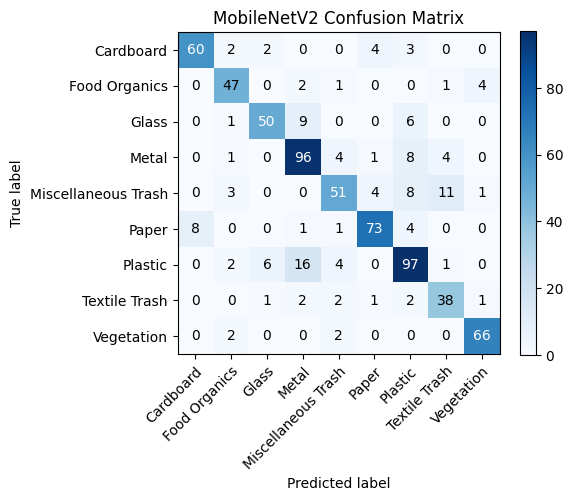

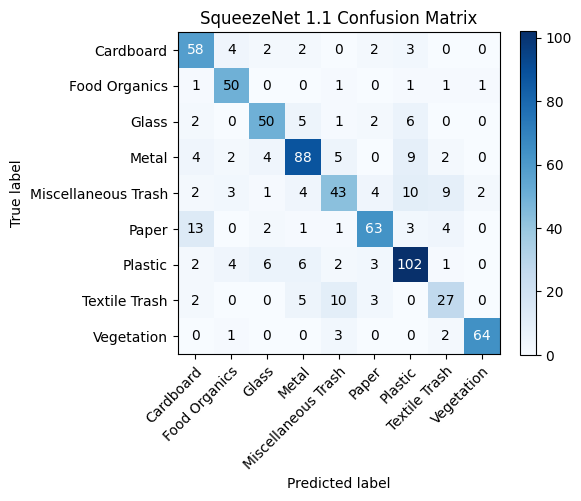

In [ ]:
class_names = full_dataset.classes

# Plot for MobileNetV2
plot_confusion_matrix(mb_labels, mb_preds, class_names, title="MobileNetV2 Confusion Matrix")

# Plot for SqueezeNet
plot_confusion_matrix(sq_labels, sq_preds, class_names, title="SqueezeNet 1.1 Confusion Matrix")

Model Size and Parameter Counts

In [ ]:
def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

def model_size_mb(model):
    torch.save(model.state_dict(), "temp.pth")
    size_mb = os.path.getsize("temp.pth") / (1024 ** 2)
    os.remove("temp.pth")
    return size_mb

import os
for name, model in [("MobileNetV2", mobilenet), ("SqueezeNet1.1", squeezenet)]:
    total, trainable = count_params(model)
    size = model_size_mb(model)
    print(f"{name}: {total:,} params ({trainable:,} trainable), {size:.2f} MB")

MobileNetV2: 2,235,401 params (2,235,401 trainable), 8.74 MB
SqueezeNet1.1: 727,113 params (727,113 trainable), 2.79 MB
